# Objective

The objective of this experiment is to build a Denoising Autoencoder using the MNIST dataset. The model is trained using noisy digit images as input and clean digit images as target output. The goal is to learn how to remove noise from images and reconstruct clearer versions of the handwritten digits.

# Methodology

1. Downloaded the MNIST dataset using KaggleHub.
2. Preprocessed the images by normalizing pixel values between 0 and 1
3. Added Gaussian noise to the original images to create noisy inputs.
4. Built a Convolutional Denoising Autoencoder consisting of:
   - Encoder layers for feature extraction.
   - Decoder layers for image reconstruction.
5. Trained the model using noisy images as input and clean images as target output.
6. Generated denoised images from the test set and compared them with the original and noisy images.

# Observations

- The autoencoder successfully learned to remove a significant amount of noise from the images.
- The reconstructed images were much clearer than the noisy inputs.
- Most digits retained their original shape and structure after reconstruction.
- A slight loss of fine details was observed in some images, which is expected when the model smooths out noise.
- The validation loss decreased during training, indicating that the model was learning meaningful representations of the digit images.

# Results and Analysis

The denoising autoencoder successfully learned to reconstruct clean digit images from noisy inputs. The reconstructed outputs retained the overall digit structure while removing a significant portion of the Gaussian noise.

The training and validation losses decreased consistently during training, indicating effective learning and good generalization. Visual inspection showed that most digits were reconstructed accurately, although some fine details were slightly smoothed. This behavior is expected because the network prioritizes removing noise over preserving every pixel-level detail.

The calculated Mean Squared Error (MSE) further confirmed that the reconstructed images were close to the original images.

Overall, the model demonstrated that convolutional autoencoders can effectively perform image denoising while maintaining the essential characteristics of handwritten digits.

In [1]:
!unzip -q /content/archive.zip

replace mnist_png/testing/0/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import cv2
from tensorflow.keras.layers import BatchNormalization

np.random.seed(42)
tf.random.set_seed(42)

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [3]:
dataset_path = "/content/mnist_png"

train_path = os.path.join(dataset_path, "training")
test_path = os.path.join(dataset_path, "testing")

print(train_path)
print(test_path)

/content/mnist_png/training
/content/mnist_png/testing


In [4]:
x_train = []
y_train = []

for label in sorted(os.listdir(train_path)):

    label_folder = os.path.join(train_path, label)

    for image_name in os.listdir(label_folder):

        image_path = os.path.join(label_folder, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        img = img.astype("float32") / 255.0

        x_train.append(img)
        y_train.append(int(label))

x_train = np.array(x_train)
y_train = np.array(y_train)

print("Training Images:", x_train.shape)

Training Images: (60000, 28, 28)


In [5]:
x_test = []
y_test = []

for label in sorted(os.listdir(test_path)):

    label_folder = os.path.join(test_path, label)

    for image_name in os.listdir(label_folder):

        image_path = os.path.join(label_folder, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        img = img.astype("float32") / 255.0

        x_test.append(img)
        y_test.append(int(label))

x_test = np.array(x_test)
y_test = np.array(y_test)

print("Testing Images:", x_test.shape)

Testing Images: (10000, 28, 28)


In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [7]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0, 1)
x_test_noisy = np.clip(x_test_noisy, 0, 1)

print("Gaussian Noise Added")
print("Noise Factor =", noise_factor)

Gaussian Noise Added
Noise Factor = 0.5


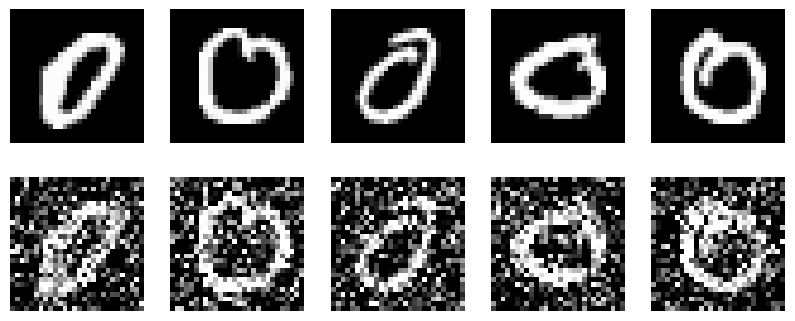

In [8]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [12]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mse']
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.1598 - mse: 0.0266 - val_loss: 0.1150 - val_mse: 0.0168
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1008 - mse: 0.0123 - val_loss: 0.0989 - val_mse: 0.0119
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0982 - mse: 0.0116 - val_loss: 0.0965 - val_mse: 0.0111
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0968 - mse: 0.0112 - val_loss: 0.0957 - val_mse: 0.0109
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0959 - mse: 0.0109 - val_loss: 0.0951 - val_mse: 0.0107
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0952 - mse: 0.0107 - val_loss: 0.0947 - val_mse: 0.0105
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0947 - mse: 0.0105 - val_loss: 0.0943 - val_mse: 0.0104
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0943 - mse: 0.0104 - val_loss: 0.0941 - val_mse: 0.0104
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - 

In [14]:
denoised_images = autoencoder.predict(x_test_noisy)

mse = np.mean((x_test - denoised_images) ** 2)
print("Mean Squared Error:", mse)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Mean Squared Error: 0.010211415


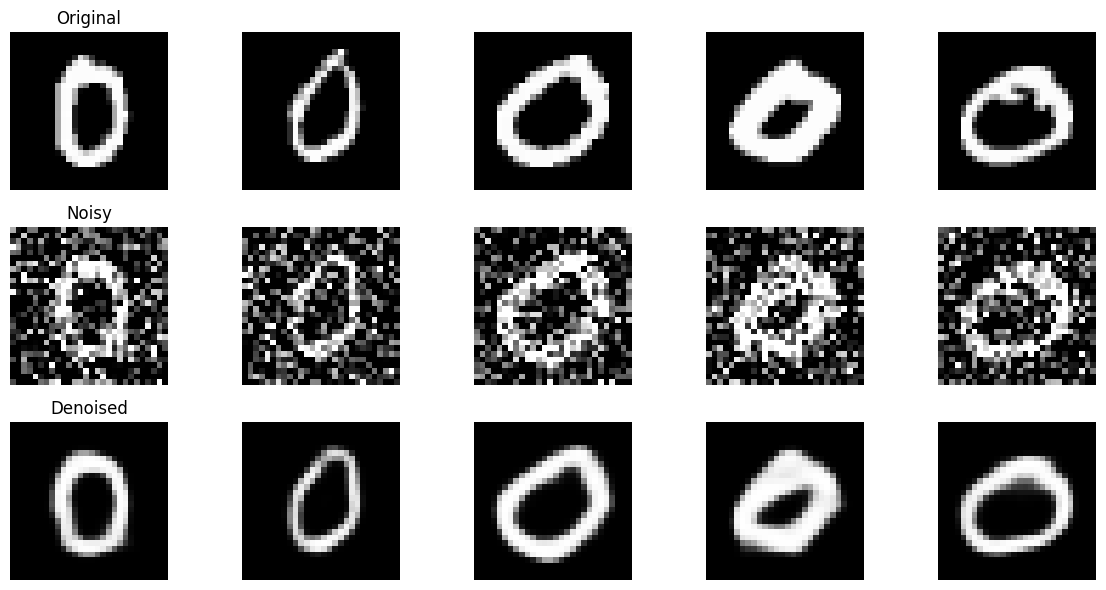

In [15]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Noisy")

    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Denoised")

plt.tight_layout()
plt.show()

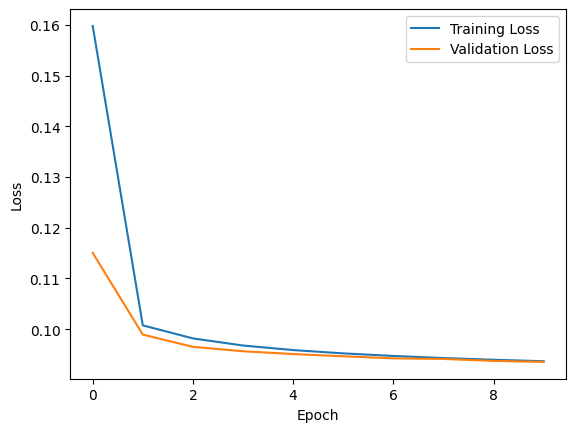

In [16]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()